In [67]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
OUTPUTS_DIR = Path("/Users/hyeon/SeSAC_Project/PoC/run/test1/outputs")
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

In [10]:
pose_data

{'frames': [{'image_path': 'run/test1/inputs/00000001.png',
   'people': [{'track_id': 0,
     'bbox': [152.0149383544922,
      257.417236328125,
      539.0452270507812,
      886.3115844726562],
     'bbox_score': 1.0,
     'keypoints': [[263.64280700683594, 320.0609836578369],
      [272.8551263809204, 309.8250732421875],
      [265.6899890899658, 308.80148220062256],
      [301.51567554473877, 321.08457469940186],
      [323.01108741760254, 319.037392616272],
      [296.39772033691406, 384.5472192764282],
      [355.76600074768066, 387.61799240112305],
      [288.20899200439453, 471.55245780944824],
      [421.2758274078369, 444.93909072875977],
      [225.7699384689331, 474.62323093414307],
      [383.4029588699341, 513.5196905136108],
      [350.64804553985596, 573.9115619659424],
      [332.223406791687, 572.8879709243774],
      [426.3937826156616, 715.1671257019043],
      [255.4540786743164, 692.6481227874756],
      [540.0123882293701, 808.313910484314],
      [229.86430263

In [12]:
pose_data["frames"].__len__()

500

In [24]:
Halpe_26_keypoints = {
    0: "nose",
    1: "left_eye",
    2: "right_eye",
    3: "left_ear",
    4: "right_ear",
    5: "left_shoulder",
    6: "right_shoulder",
    7: "left_elbow",
    8: "right_elbow",
    9: "left_wrist",
    10: "right_wrist",
    11: "left_hip",
    12: "right_hip",
    13: "left_knee",
    14: "right_knee",
    15: "left_ankle",
    16: "right_ankle",
    17: "head",
    18: "neck",
    19: "hip_center",
    20: "left_big_toe",
    21: "right_big_toe",
    22: "left_small_toe",
    23: "right_small_toe",
    24: "left_heel",
    25: "right_heel",
}

In [ ]:
def hpe2pd(pose_data: dict) -> pd.DataFrame:
    """
    hpe json 데이터를 pandas DataFrame으로 변경
    Returns:
        pd.DataFrame has bbox(4), keypoints(26)
    """
    rows = []
    
    for frame in pose_data["frames"]:
        row = {}

        if frame['people'] == []:
            # 사람이 포착되지 않음.
            continue
        bbox = frame['people'][0]["bbox"]
        row["bbox_left"], row["bbox_up"], row["bbox_right"], row["bbox_down"] = bbox

        for i, xy in enumerate(frame['people'][0]['keypoints']):
            row[f"{Halpe_26_keypoints[i]}_x"] = xy[0]
            row[f"{Halpe_26_keypoints[i]}_y"] = xy[1]
        rows.append(row)
    
    return pd.DataFrame.from_records(rows)

In [81]:
df = hpe2pd(pose_data)
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,152.014938,257.417236,539.045227,886.311584,263.642807,320.060984,272.855126,309.825073,265.689989,308.801482,...,169.472431,830.832913,547.177526,830.832913,174.590386,831.856504,554.342663,811.384684,232.935076,866.658600
1,148.983856,259.010376,540.477356,889.514099,263.659964,321.814432,272.895858,310.526117,264.686174,309.499907,...,165.143759,826.709982,549.972684,814.395456,170.274811,830.814824,555.103737,784.635353,225.690177,870.837032
2,155.050430,246.987915,540.338440,898.366150,263.939736,321.412941,272.421224,310.811082,266.060108,308.690711,...,172.763744,831.362364,558.671434,818.640133,174.884116,836.663293,558.671434,769.871581,232.134158,876.950358
3,171.627380,249.528503,538.780334,906.648193,263.224217,326.748658,272.849994,316.053351,266.432809,314.983820,...,185.148476,843.331999,509.216278,795.203116,188.357068,846.540591,549.858445,757.769541,251.459380,886.113228
4,195.288849,247.788712,536.680847,904.332825,266.605623,332.421364,275.154375,321.735424,268.742811,320.666830,...,207.832954,869.924135,521.999584,772.682083,213.175924,865.649759,540.165682,742.761452,278.360157,887.021639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,168.465363,172.927231,536.961609,896.119812,299.745295,261.442968,310.338936,246.141041,303.276508,246.141041,...,213.819093,794.656246,191.454739,854.686879,212.642022,616.918486,260.901943,873.520020,237.360518,689.896904
496,153.204254,170.053986,536.448914,903.936951,299.436704,261.072710,310.186942,246.739059,303.020116,246.739059,...,205.073500,796.195665,175.211726,845.168971,230.157389,871.447330,239.713157,881.003098,221.796093,994.477831
497,158.740265,169.474915,537.924316,914.639099,299.818982,263.105580,310.734473,248.551592,304.670311,248.551592,...,210.069388,787.049130,179.748579,851.329241,201.579562,881.650049,242.815861,888.927042,228.261873,1006.571775
498,182.119629,171.504730,537.209290,926.816162,304.343796,266.410416,311.719884,250.428892,305.573144,251.658240,...,219.518778,796.259414,201.078557,871.249644,246.564436,901.983344,265.004657,904.442040,384.251421,1020.000755


### 결측치 검사

In [66]:
df.isna().sum().sum()

np.int64(0)

In [80]:
df.describe()

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,left_heel_x,left_heel_y,right_heel_x,right_heel_y,vx,vy,speed,ax,ay,acceleration
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,499.000000,499.000000,499.000000,498.000000,498.000000,498.000000
mean,162.847340,232.351348,502.112439,877.058101,243.193679,303.510557,251.696771,291.943643,246.007058,291.023631,...,373.110222,778.296871,375.940731,779.267022,-12.000009,3.924961,942.661170,37.711969,53.426141,16325.338554
std,41.336241,33.485267,48.815223,33.650965,29.272233,25.933325,29.688319,26.988130,28.988261,27.074610,...,128.088969,103.227012,121.694103,94.186155,1140.227627,681.888026,935.337162,39632.035324,24039.410429,43376.754524
min,59.065521,169.474915,341.036316,783.917542,177.831367,261.072710,185.650829,246.141041,180.763666,246.141041,...,129.184811,104.357758,130.498568,464.993259,-9166.191859,-4900.940406,87.610660,-305995.396243,-259312.669635,583.624797
25%,132.095627,204.043594,474.250633,853.622055,218.660393,283.309742,225.650847,270.987038,220.939619,269.445804,...,250.129033,700.375028,259.028706,694.922923,-665.665224,-288.274849,615.312877,-4055.011968,-3205.773210,4323.562087
50%,160.034721,227.917427,532.312683,878.133240,249.539800,297.762160,258.226678,286.224860,251.432387,285.311151,...,377.922865,802.173305,388.616856,795.459264,-109.884392,68.085905,777.779071,12.735360,259.935459,6680.331662
75%,190.962036,260.505966,538.887283,901.314514,262.355153,323.504466,270.575039,313.239876,264.735277,312.940282,...,486.125704,856.389764,481.125775,856.103950,663.255005,318.435882,1007.226232,5412.529127,3403.852073,9742.128687
max,269.190460,300.956482,541.693787,953.922729,304.343796,362.039848,312.823770,351.754200,309.124302,350.793439,...,652.513398,925.997866,561.575143,1020.000755,10536.667834,5471.566379,10553.067735,492571.492328,137549.016774,492625.262104


In [63]:
left_ankle_x = df["left_ankle_x"]
type(left_ankle_x)

pandas.Series

In [68]:
details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    details_data = json.load(file)

In [99]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,152.014938,257.417236,539.045227,886.311584,263.642807,320.060984,272.855126,309.825073,265.689989,308.801482,...,169.472431,830.832913,547.177526,830.832913,174.590386,831.856504,554.342663,811.384684,232.935076,866.658600
1,148.983856,259.010376,540.477356,889.514099,263.659964,321.814432,272.895858,310.526117,264.686174,309.499907,...,165.143759,826.709982,549.972684,814.395456,170.274811,830.814824,555.103737,784.635353,225.690177,870.837032
2,155.050430,246.987915,540.338440,898.366150,263.939736,321.412941,272.421224,310.811082,266.060108,308.690711,...,172.763744,831.362364,558.671434,818.640133,174.884116,836.663293,558.671434,769.871581,232.134158,876.950358
3,171.627380,249.528503,538.780334,906.648193,263.224217,326.748658,272.849994,316.053351,266.432809,314.983820,...,185.148476,843.331999,509.216278,795.203116,188.357068,846.540591,549.858445,757.769541,251.459380,886.113228
4,195.288849,247.788712,536.680847,904.332825,266.605623,332.421364,275.154375,321.735424,268.742811,320.666830,...,207.832954,869.924135,521.999584,772.682083,213.175924,865.649759,540.165682,742.761452,278.360157,887.021639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,168.465363,172.927231,536.961609,896.119812,299.745295,261.442968,310.338936,246.141041,303.276508,246.141041,...,213.819093,794.656246,191.454739,854.686879,212.642022,616.918486,260.901943,873.520020,237.360518,689.896904
496,153.204254,170.053986,536.448914,903.936951,299.436704,261.072710,310.186942,246.739059,303.020116,246.739059,...,205.073500,796.195665,175.211726,845.168971,230.157389,871.447330,239.713157,881.003098,221.796093,994.477831
497,158.740265,169.474915,537.924316,914.639099,299.818982,263.105580,310.734473,248.551592,304.670311,248.551592,...,210.069388,787.049130,179.748579,851.329241,201.579562,881.650049,242.815861,888.927042,228.261873,1006.571775
498,182.119629,171.504730,537.209290,926.816162,304.343796,266.410416,311.719884,250.428892,305.573144,251.658240,...,219.518778,796.259414,201.078557,871.249644,246.564436,901.983344,265.004657,904.442040,384.251421,1020.000755


In [98]:
df["bbox_down"].diff()

0            NaN
1       3.202515
2       8.852051
3       8.282043
4      -2.315369
         ...    
495    18.192444
496     7.817139
497    10.702148
498    12.177063
499     6.946533
Name: bbox_down, Length: 500, dtype: float64

In [ ]:
def vel_acc(df: pd.DataFrame, keypoints: list[str] = None,fps: float | int = 60):
    """
    정해진 형식의 df에서 구하고자 하는 키포인트의 속력(vel)과 가속력(acc)를 구한다.
    Returns:
        pd.DataFrame
    """
    if fps <= 0:
        raise ValueError("fps는 0보다 커야 합니다.")
    
    if keypoints is None:
        keypoints = list(Halpe_26_keypoints.values())

    dt = 1 / fps

    res = pd.DataFrame()

    for key in keypoints:
        vx = df[f"{key}_x"].diff() / dt
        vy = df[f"{key}_y"].diff() / dt
        ax = vx.diff() / dt
        ay = vy.diff() / dt
        res[f"{key}_vel"] = np.hypot(vx, vy)
        res[f"{key}_acc"] = np.hypot(ax, ay)

    return res

In [101]:
vel_acc_df = vel_acc(df, fps=25)
vel_acc_df

,nose_vel,nose_acc,left_eye_vel,left_eye_acc,right_eye_vel,right_eye_acc,left_ear_vel,left_ear_acc,right_ear_vel,right_ear_acc,...,right_big_toe_vel,right_big_toe_acc,left_small_toe_vel,left_small_toe_acc,right_small_toe_vel,right_small_toe_acc,left_heel_vel,left_heel_acc,right_heel_vel,right_heel_acc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43.838311,NaN,17.555651,NaN,30.572051,NaN,43.994231,NaN,18.602106,NaN,...,149.448917,NaN,416.835480,NaN,110.987854,NaN,669.003893,NaN,209.087091,NaN
2,12.233853,1356.801416,13.840219,413.976078,39.862990,1759.639518,45.412897,226.636542,92.483875,2046.985611,...,223.199495,9265.538516,241.978210,13442.630425,186.162365,7046.930808,379.718168,7693.614552,222.060865,8640.593954
3,134.586968,3639.312114,131.494357,3149.342387,157.603415,4482.832551,161.111069,2973.762709,211.257401,6263.664881,...,430.590991,5457.399508,1368.189086,40253.847293,417.643287,6085.193373,374.272762,7914.736520,534.685884,8273.311994
4,165.101281,2569.225662,153.289200,1204.053729,153.363756,1269.435880,141.768354,578.131048,197.491405,4281.761086,...,873.830384,11178.633096,647.403393,38903.251296,783.077232,9142.042194,446.648903,1897.687822,672.902777,7002.374906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40.521838,2369.567575,90.581365,666.459182,53.336718,3565.524521,80.957296,2504.433588,443.265358,16055.262035,...,1444.858725,261999.963219,976.636133,7739.990181,587.044701,293598.244969,1088.497711,7023.602283,5140.298372,332456.810140
496,12.049884,818.871367,15.425772,2643.492120,16.266565,1725.345435,39.980389,1518.324771,158.123774,14954.713156,...,222.001148,34613.681137,470.655162,14384.214551,6378.269780,156160.304791,561.783502,13244.494191,7624.458696,143352.741167
497,51.712532,1562.790679,47.335680,875.977794,61.280191,1412.848490,56.959565,1526.729464,70.398304,5689.030440,...,260.549905,10879.631615,191.265466,16269.316893,758.612092,155397.472399,212.743503,15184.682062,342.846340,183322.169700
498,140.080080,2708.385685,53.005243,276.652910,80.879408,934.010439,58.804254,2194.287099,206.293959,3398.187541,...,329.886645,11805.826510,729.636205,13569.126766,1234.170229,46410.615340,676.876017,12837.673009,3914.163100,93456.079329


In [102]:
vel_acc_df = vel_acc_df.iloc[2:]

In [106]:
vel_acc_df

,nose_vel,nose_acc,left_eye_vel,left_eye_acc,right_eye_vel,right_eye_acc,left_ear_vel,left_ear_acc,right_ear_vel,right_ear_acc,...,right_big_toe_vel,right_big_toe_acc,left_small_toe_vel,left_small_toe_acc,right_small_toe_vel,right_small_toe_acc,left_heel_vel,left_heel_acc,right_heel_vel,right_heel_acc
2,12.233853,1356.801416,13.840219,413.976078,39.862990,1759.639518,45.412897,226.636542,92.483875,2046.985611,...,223.199495,9265.538516,241.978210,13442.630425,186.162365,7046.930808,379.718168,7693.614552,222.060865,8640.593954
3,134.586968,3639.312114,131.494357,3149.342387,157.603415,4482.832551,161.111069,2973.762709,211.257401,6263.664881,...,430.590991,5457.399508,1368.189086,40253.847293,417.643287,6085.193373,374.272762,7914.736520,534.685884,8273.311994
4,165.101281,2569.225662,153.289200,1204.053729,153.363756,1269.435880,141.768354,578.131048,197.491405,4281.761086,...,873.830384,11178.633096,647.403393,38903.251296,783.077232,9142.042194,446.648903,1897.687822,672.902777,7002.374906
5,158.808149,4294.169313,155.001174,3107.043758,95.815151,2706.518992,156.162267,434.717351,215.441172,4561.418717,...,717.064928,5950.583891,402.179644,12198.728875,675.044547,2770.733563,215.215298,5864.765641,661.426149,791.382148
6,107.303450,2871.811062,129.936940,1656.248572,129.744989,1348.216330,133.609390,1038.144396,158.559476,5455.733581,...,739.408632,8121.224785,216.661291,14337.918533,786.680707,10223.130100,501.621979,7637.145905,678.781720,1175.568322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40.521838,2369.567575,90.581365,666.459182,53.336718,3565.524521,80.957296,2504.433588,443.265358,16055.262035,...,1444.858725,261999.963219,976.636133,7739.990181,587.044701,293598.244969,1088.497711,7023.602283,5140.298372,332456.810140
496,12.049884,818.871367,15.425772,2643.492120,16.266565,1725.345435,39.980389,1518.324771,158.123774,14954.713156,...,222.001148,34613.681137,470.655162,14384.214551,6378.269780,156160.304791,561.783502,13244.494191,7624.458696,143352.741167
497,51.712532,1562.790679,47.335680,875.977794,61.280191,1412.848490,56.959565,1526.729464,70.398304,5689.030440,...,260.549905,10879.631615,191.265466,16269.316893,758.612092,155397.472399,212.743503,15184.682062,342.846340,183322.169700
498,140.080080,2708.385685,53.005243,276.652910,80.879408,934.010439,58.804254,2194.287099,206.293959,3398.187541,...,329.886645,11805.826510,729.636205,13569.126766,1234.170229,46410.615340,676.876017,12837.673009,3914.163100,93456.079329


In [104]:
#    13: "left_knee",
#    14: "right_knee",

In [116]:
lkv = vel_acc_df["left_knee_vel"].to_frame()
lka = vel_acc_df["left_knee_acc"].to_frame()


In [110]:
fps = 25

In [124]:
lkv['time_s'] = (vel_acc_df.index.to_numpy() - 2) / fps
lka['time_s'] = (vel_acc_df.index.to_numpy() - 2) / fps

In [121]:
lkv

,left_knee_vel,time_s
2,399.888089,0.00
3,375.320913,0.04
4,429.104260,0.08
5,441.365921,0.12
6,416.946763,0.16
...,...,...
495,375.854241,19.72
496,537.566029,19.76
497,519.320804,19.80
498,419.025666,19.84


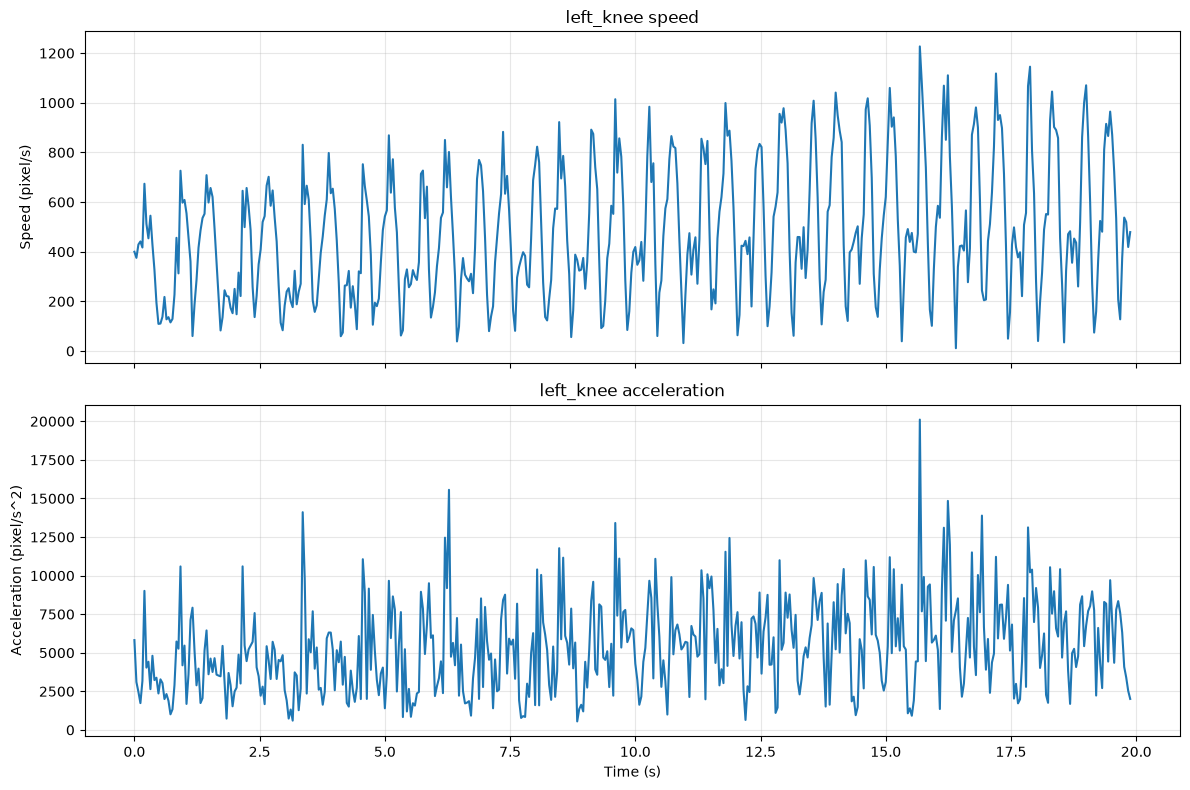

In [125]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

axes[0].plot(
    lkv["time_s"],
    lkv["left_knee_vel"],
    color="tab:blue",
    linewidth=1.5,
)

axes[0].set_title("left_knee speed")
axes[0].set_ylabel("Speed (pixel/s)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    lka["time_s"],
    lka["left_knee_acc"],
    color="tab:blue",
    linewidth=1.5,
)

axes[1].set_title("left_knee acceleration")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (pixel/s^2)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()